# TrashNet — MobileNetV3Small con y sin Optuna

Notebook definitivo del proyecto de visión computacional.

Este flujo incluye:

1. Importación y revisión del dataset.
2. Modelo base con hiperparámetros definidos manualmente.
3. Entrenamiento en dos fases:
   - **Fase 1:** transferencia de aprendizaje con MobileNetV3 congelada.
   - **Fase 2:** *fine-tuning* de las últimas capas.
4. Optimización automática de hiperparámetros con **Optuna**.
5. Entrenamiento final del modelo optimizado.
6. Comparación completa entre ambos modelos:
   - accuracy, precision, recall y F1;
   - curvas de entrenamiento;
   - matrices de confusión;
   - reportes de clasificación;
   - curvas ROC y AUC;
   - resumen final comparativo.

> El conjunto de test se utiliza únicamente al final para comparar los modelos terminados.


In [1]:
# 1. Importaciones y configuración general

import os
import gc
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import optuna

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Uso progresivo de memoria GPU, cuando exista
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as error:
        print("No se pudo configurar memory growth:", error)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

EPOCHS_FASE1 = 25
EPOCHS_FASE2 = 15

# Búsqueda rápida de Optuna
OPTUNA_TRIALS = 10
OPTUNA_EPOCHS = 8

BASE_DIR = "../dataset"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "validation")
TEST_DIR = os.path.join(BASE_DIR, "test")

CLASSES = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]
N_CLASSES = len(CLASSES)

MODEL_DIR = "modelo_guardado"
RESULTS_DIR = "resultados"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("Optuna:", optuna.__version__)
print("GPU detectada:", gpus if gpus else "No; se utilizará CPU")


TensorFlow: 2.21.0
Optuna: 4.9.0
GPU detectada: No; se utilizará CPU


In [2]:
# 2. Validación de la estructura del dataset

def validar_directorio_dataset(ruta, nombre):
    if not os.path.isdir(ruta):
        raise FileNotFoundError(
            f"No existe el directorio {nombre}: {ruta}"
        )

    clases_encontradas = sorted(
        carpeta for carpeta in os.listdir(ruta)
        if os.path.isdir(os.path.join(ruta, carpeta))
    )

    faltantes = sorted(set(CLASSES) - set(clases_encontradas))
    if faltantes:
        raise ValueError(
            f"Faltan clases en {nombre}: {faltantes}"
        )

    print(f"{nombre}: {clases_encontradas}")

validar_directorio_dataset(TRAIN_DIR, "Train")
validar_directorio_dataset(VALID_DIR, "Validation")
validar_directorio_dataset(TEST_DIR, "Test")


Train: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Validation: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Test: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [3]:
# 3. Conteo de imágenes por clase

def contar_imagenes_por_clase(ruta):
    extensiones = (".jpg", ".jpeg", ".png", ".webp")
    conteo = {}

    for clase in CLASSES:
        carpeta = os.path.join(ruta, clase)
        conteo[clase] = sum(
            archivo.lower().endswith(extensiones)
            for archivo in os.listdir(carpeta)
        )

    return conteo

train_count = contar_imagenes_por_clase(TRAIN_DIR)
valid_count = contar_imagenes_por_clase(VALID_DIR)
test_count = contar_imagenes_por_clase(TEST_DIR)

conteos_df = pd.DataFrame({
    "train": train_count,
    "validation": valid_count,
    "test": test_count
})

print(conteos_df)
print("\nTotales:")
print(conteos_df.sum())


           train  validation  test
cardboard    282          60    61
glass        350          75    76
metal        287          61    62
paper        415          89    90
plastic      337          72    73
trash         95          20    22

Totales:
train         1766
validation     377
test           384
dtype: int64


In [4]:
# 4. Pesos de clase para compensar el desbalance

class_indices = {
    clase: indice
    for indice, clase in enumerate(CLASSES)
}

y_train_weights = []
for clase in CLASSES:
    y_train_weights.extend(
        [class_indices[clase]] * train_count[clase]
    )

y_train_weights = np.asarray(y_train_weights)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(N_CLASSES),
    y=y_train_weights
)

class_weights = {
    indice: float(peso)
    for indice, peso in enumerate(class_weights_array)
}

print("Pesos por clase:")
for indice, peso in class_weights.items():
    print(f"{indice} - {CLASSES[indice]:10s}: {peso:.4f}")


Pesos por clase:
0 - cardboard : 1.0437
1 - glass     : 0.8410
2 - metal     : 1.0256
3 - paper     : 0.7092
4 - plastic   : 0.8734
5 - trash     : 3.0982


In [5]:
# 5. Importación del dataset

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=CLASSES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=CLASSES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=CLASSES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Clases:", CLASSES)


Found 1766 files belonging to 6 classes.
Found 377 files belonging to 6 classes.
Found 384 files belonging to 6 classes.
Clases: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [6]:
# 6. Data augmentation

def crear_data_augmentation():
    return keras.Sequential(
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.10),
            layers.RandomZoom(0.10),
            layers.RandomContrast(0.10),
            layers.RandomTranslation(
                height_factor=0.05,
                width_factor=0.05
            ),
        ],
        name="data_augmentation"
    )


## Parte A — Modelo sin Optuna

En esta versión los hiperparámetros se definen manualmente:

- capa densa: 128 neuronas;
- dropout: 0,35;
- optimizador: Adam;
- learning rate de fase 1: 3e-4;
- fine-tuning: últimas 20 capas con learning rate 1e-5.


In [7]:
# 7. Constructor general de MobileNetV3Small

def construir_modelo(
    dense_units,
    dropout_rate,
    optimizer_name,
    learning_rate,
    nombre_modelo
):
    base_model = keras.applications.MobileNetV3Small(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights="imagenet",
        include_preprocessing=True
    )

    # Fase 1: backbone congelado
    base_model.trainable = False

    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = crear_data_augmentation()(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(N_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name=nombre_modelo)

    if optimizer_name.lower() == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name.lower() == "rmsprop":
        optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        raise ValueError(f"Optimizador no soportado: {optimizer_name}")

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model, base_model


In [8]:
# 8. Modelo base sin Optuna — Fase 1

keras.backend.clear_session()

BASE_DENSE_UNITS = 128
BASE_DROPOUT = 0.35
BASE_LR = 3e-4
BASE_OPTIMIZER = "adam"

model_base, backbone_base = construir_modelo(
    dense_units=BASE_DENSE_UNITS,
    dropout_rate=BASE_DROPOUT,
    optimizer_name=BASE_OPTIMIZER,
    learning_rate=BASE_LR,
    nombre_modelo="trashnet_mobilenetv3_sin_optuna"
)

model_base.summary()


Model: "trashnet_mobilenetv3_sin_optuna"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,013,750 (3.87 MB)

 Trainable params: 74,630 (291.52 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [9]:
# 9. Entrenamiento del modelo base — Fase 1

callbacks_base_fase1 = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=6,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

history_base_fase1 = model_base.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_FASE1,
    class_weight=class_weights,
    callbacks=callbacks_base_fase1,
    verbose=1
)


Epoch 1/25


c:\Users\tomas\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 139ms/step - accuracy: 0.3856 - loss: 1.5653 - val_accuracy: 0.5756 - val_loss: 1.1054 - learning_rate: 3.0000e-04
Epoch 2/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - accuracy: 0.6234 - loss: 1.0822 - val_accuracy: 0.6658 - val_loss: 0.8652 - learning_rate: 3.0000e-04
Epoch 3/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - accuracy: 0.6789 - loss: 0.9283 - val_accuracy: 0.6950 - val_loss: 0.7798 - learning_rate: 3.0000e-04
Epoch 4/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - accuracy: 0.7282 - loss: 0.7855 - val_accuracy: 0.7215 - val_loss: 0.7411 - learning_rate: 3.0000e-04
Epoch 5/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 137ms/step - accuracy: 0.7424 - loss: 0.7258 - val_accuracy: 0.7692 - val_loss: 0.6543 - learning_rate: 3.0000e-04
Epoch 6/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 137ms/step - accuracy: 0.7441 - loss: 0.7028 - val_accuracy: 0.7798 - val_loss: 0.6102 - learning_rate: 3.0000e-04
Epoch 7/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 197ms/step - accuracy: 0.7973 - 

In [10]:
# 10. Modelo base — Fase 2: fine-tuning

backbone_base.trainable = True

for layer in backbone_base.layers[:-20]:
    layer.trainable = False

for layer in backbone_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model_base.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_base_fase2 = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

history_base_fase2 = model_base.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_FASE2,
    class_weight=class_weights,
    callbacks=callbacks_base_fase2,
    verbose=1
)


Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 28s 255ms/step - accuracy: 0.8630 - loss: 0.3975 - val_accuracy: 0.8408 - val_loss: 0.4502 - learning_rate: 1.0000e-05
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 221ms/step - accuracy: 0.8658 - loss: 0.3987 - val_accuracy: 0.8408 - val_loss: 0.4452 - learning_rate: 1.0000e-05
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 216ms/step - accuracy: 0.8584 - loss: 0.3915 - val_accuracy: 0.8355 - val_loss: 0.4394 - learning_rate: 1.0000e-05
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 173ms/step - accuracy: 0.8766 - loss: 0.3699 - val_accuracy: 0.8408 - val_loss: 0.4389 - learning_rate: 1.0000e-05
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 191ms/step - accuracy: 0.8669 - loss: 0.3690 - val_accuracy: 0.8382 - val_loss: 0.4376 - learning_rate: 1.0000e-05
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 176ms/step - accuracy: 0.8703 - loss: 0.3710 - val_accuracy: 0.8408 - val_loss: 0.4345 - learning_rate: 1.0000e-05
Epoch 6: early stopping
Restoring model weights from the e

In [11]:
# 11. Guardar el modelo sin Optuna

RUTA_MODELO_BASE = os.path.join(
    MODEL_DIR,
    "trashnet_mobilenetv3_sin_optuna.keras"
)

model_base.save(RUTA_MODELO_BASE)
print("Modelo sin Optuna guardado en:", RUTA_MODELO_BASE)


Modelo sin Optuna guardado en: modelo_guardado\trashnet_mobilenetv3_sin_optuna.keras


## Parte B — Optimización con Optuna

Optuna probará automáticamente distintas combinaciones de:

- número de neuronas de la capa densa;
- dropout;
- learning rate;
- optimizador.

Cada combinación corresponde a un **trial**. El estudio maximiza la mejor accuracy de validación obtenida durante una búsqueda corta. Luego se reconstruye y entrena completamente el modelo ganador.


In [12]:
# 12. Función objetivo para Optuna

def objective(trial):
    keras.backend.clear_session()
    gc.collect()

    dense_units = trial.suggest_categorical(
        "dense_units",
        [64, 128, 256]
    )

    dropout_rate = trial.suggest_float(
        "dropout_rate",
        0.20,
        0.50,
        step=0.05
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-5,
        1e-3,
        log=True
    )

    optimizer_name = trial.suggest_categorical(
        "optimizer",
        ["adam", "rmsprop"]
    )

    model_trial, _ = construir_modelo(
        dense_units=dense_units,
        dropout_rate=dropout_rate,
        optimizer_name=optimizer_name,
        learning_rate=learning_rate,
        nombre_modelo=f"trial_{trial.number}"
    )

    callbacks_trial = [
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=3,
            mode="max",
            restore_best_weights=True,
            verbose=0
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-7,
            verbose=0
        )
    ]

    history_trial = model_trial.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=OPTUNA_EPOCHS,
        class_weight=class_weights,
        callbacks=callbacks_trial,
        verbose=0
    )

    best_val_accuracy = float(
        max(history_trial.history["val_accuracy"])
    )

    trial.set_user_attr(
        "epochs_executed",
        len(history_trial.history["accuracy"])
    )

    print(
        f"Trial {trial.number:02d} | "
        f"val_accuracy={best_val_accuracy:.4f} | "
        f"{trial.params}"
    )

    del model_trial
    gc.collect()

    return best_val_accuracy


In [13]:
# 13. Ejecutar el estudio de Optuna

sampler = optuna.samplers.TPESampler(seed=SEED)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    study_name="TrashNet_MobileNetV3_Optuna"
)

study.optimize(
    objective,
    n_trials=OPTUNA_TRIALS
)

print("\nMejor trial:", study.best_trial.number)
print(f"Mejor val_accuracy rápida: {study.best_value:.4f}")

print("\nMejores hiperparámetros:")
for parametro, valor in study.best_params.items():
    print(f"{parametro}: {valor}")


[I 2026-08-05 17:22:58,429] A new study created in memory with name: TrashNet_MobileNetV3_Optuna
[I 2026-08-05 17:24:22,169] Trial 0 finished with value: 0.5517241358757019 and parameters: {'dense_units': 128, 'dropout_rate': 0.4, 'learning_rate': 2.0513382630874486e-05, 'optimizer': 'adam'}. Best is trial 0 with value: 0.5517241358757019.


Trial 00 | val_accuracy=0.5517 | {'dense_units': 128, 'dropout_rate': 0.4, 'learning_rate': 2.0513382630874486e-05, 'optimizer': 'adam'}


[I 2026-08-05 17:25:47,887] Trial 1 finished with value: 0.8541114330291748 and parameters: {'dense_units': 64, 'dropout_rate': 0.2, 'learning_rate': 0.0008706020878304854, 'optimizer': 'adam'}. Best is trial 1 with value: 0.8541114330291748.


Trial 01 | val_accuracy=0.8541 | {'dense_units': 64, 'dropout_rate': 0.2, 'learning_rate': 0.0008706020878304854, 'optimizer': 'adam'}


[I 2026-08-05 17:27:14,085] Trial 2 finished with value: 0.7771883010864258 and parameters: {'dense_units': 256, 'dropout_rate': 0.35000000000000003, 'learning_rate': 7.309539835912905e-05, 'optimizer': 'rmsprop'}. Best is trial 1 with value: 0.8541114330291748.


...

Trial 06 | val_accuracy=0.7082 | {'dense_units': 128, 'dropout_rate': 0.4, 'learning_rate': 4.201672054372529e-05, 'optimizer': 'rmsprop'}
Trial 07 | val_accuracy=0.8355 | {'dense_units': 128, 'dropout_rate': 0.5, 'learning_rate': 0.0006161049539380963, 'optimizer': 'rmsprop'}


[I 2026-08-05 17:35:11,903] Trial 7 finished with value: 0.8355437517166138 and parameters: {'dense_units': 128, 'dropout_rate': 0.5, 'learning_rate': 0.0006161049539380963, 'optimizer': 'rmsprop'}. Best is trial 1 with value: 0.8541114330291748.
[I 2026-08-05 17:36:52,299] Trial 8 finished with value: 0.7188329100608826 and parameters: {'dense_units': 128, 'dropout_rate': 0.30000000000000004, 'learning_rate': 5.989003672254293e-05, 'optimizer': 'rmsprop'}. Best is trial 1 with value: 0.8541114330291748.


Trial 08 | val_accuracy=0.7188 | {'dense_units': 128, 'dropout_rate': 0.30000000000000004, 'learning_rate': 5.989003672254293e-05, 'optimizer': 'rmsprop'}
Trial 09 | val_accuracy=0.8488 | {'dense_units': 256, 'dropout_rate': 0.2, 'learning_rate': 0.0004021554526690286, 'optimizer': 'rmsprop'}


[I 2026-08-05 17:38:29,053] Trial 9 finished with value: 0.8488063812255859 and parameters: {'dense_units': 256, 'dropout_rate': 0.2, 'learning_rate': 0.0004021554526690286, 'optimizer': 'rmsprop'}. Best is trial 1 with value: 0.8541114330291748.



Mejor trial: 1
Mejor val_accuracy rápida: 0.8541

Mejores hiperparámetros:
dense_units: 64
dropout_rate: 0.2
learning_rate: 0.0008706020878304854
optimizer: adam


In [14]:
# 14. Tabla de todos los trials

trials_df = study.trials_dataframe(
    attrs=("number", "value", "params", "state")
)

columnas = [
    columna for columna in [
        "number",
        "value",
        "params_dense_units",
        "params_dropout_rate",
        "params_learning_rate",
        "params_optimizer",
        "state"
    ]
    if columna in trials_df.columns
]

display(trials_df[columnas].sort_values("value", ascending=False))


,number,value,params_dense_units,params_dropout_rate,params_learning_rate,params_optimizer,state
1,1,0.854111,64,0.20,0.000871,adam,COMPLETE
9,9,0.848806,256,0.20,0.000402,rmsprop,COMPLETE
7,7,0.835544,128,0.50,0.000616,rmsprop,COMPLETE
3,3,0.830239,256,0.35,0.000372,rmsprop,COMPLETE
2,2,0.777188,256,0.35,0.000073,rmsprop,COMPLETE
8,8,0.718833,128,0.30,0.000060,rmsprop,COMPLETE
6,6,0.708223,128,0.40,0.000042,rmsprop,COMPLETE
5,5,0.655172,64,0.40,0.000076,rmsprop,COMPLETE
0,0,0.551724,128,0.40,0.000021,adam,COMPLETE
4,4,0.543767,256,0.25,0.000013,rmsprop,COMPLETE


In [15]:
# 15. Crear modelo final con los parámetros ganadores

best_params = study.best_params

BEST_DENSE_UNITS = best_params["dense_units"]
BEST_DROPOUT = best_params["dropout_rate"]
BEST_LR = best_params["learning_rate"]
BEST_OPTIMIZER = best_params["optimizer"]

keras.backend.clear_session()
gc.collect()

model_optuna, backbone_optuna = construir_modelo(
    dense_units=BEST_DENSE_UNITS,
    dropout_rate=BEST_DROPOUT,
    optimizer_name=BEST_OPTIMIZER,
    learning_rate=BEST_LR,
    nombre_modelo="trashnet_mobilenetv3_optuna"
)

print("Configuración ganadora:")
print("Dense units:", BEST_DENSE_UNITS)
print("Dropout:", BEST_DROPOUT)
print("Learning rate:", BEST_LR)
print("Optimizer:", BEST_OPTIMIZER)

model_optuna.summary()


Configuración ganadora:
Dense units: 64
Dropout: 0.2
Learning rate: 0.0008706020878304854
Optimizer: adam


Model: "trashnet_mobilenetv3_optuna"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 976,438 (3.72 MB)

 Trainable params: 37,318 (145.77 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [16]:
# 16. Modelo Optuna — Fase 1

callbacks_optuna_fase1 = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=6,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

history_optuna_fase1 = model_optuna.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_FASE1,
    class_weight=class_weights,
    callbacks=callbacks_optuna_fase1,
    verbose=1
)


Epoch 1/25


c:\Users\tomas\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


56/56 ━━━━━━━━━━━━━━━━━━━━ 16s 200ms/step - accuracy: 0.5074 - loss: 1.3083 - val_accuracy: 0.6658 - val_loss: 0.8875 - learning_rate: 8.7060e-04
Epoch 2/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - accuracy: 0.6920 - loss: 0.8360 - val_accuracy: 0.7560 - val_loss: 0.6639 - learning_rate: 8.7060e-04
Epoch 3/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - accuracy: 0.7627 - loss: 0.6776 - val_accuracy: 0.7851 - val_loss: 0.5795 - learning_rate: 8.7060e-04
Epoch 4/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 157ms/step - accuracy: 0.7911 - loss: 0.5926 - val_accuracy: 0.8064 - val_loss: 0.5399 - learning_rate: 8.7060e-04
Epoch 5/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - accuracy: 0.8131 - loss: 0.5344 - val_accuracy: 0.8276 - val_loss: 0.4974 - learning_rate: 8.7060e-04
Epoch 6/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 184ms/step - accuracy: 0.8341 - loss: 0.4840 - val_accuracy: 0.8143 - val_loss: 0.5038 - learning_rate: 8.7060e-04
Epoch 7/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 218ms/step - accuracy: 0.847

In [17]:
# 17. Modelo Optuna — Fase 2: fine-tuning

backbone_optuna.trainable = True

for layer in backbone_optuna.layers[:-20]:
    layer.trainable = False

for layer in backbone_optuna.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Learning rate reducido para ajustes pequeños sobre pesos preentrenados
FINE_TUNE_LR = 1e-5

if BEST_OPTIMIZER == "adam":
    optimizer_finetune = keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LR
    )
else:
    optimizer_finetune = keras.optimizers.RMSprop(
        learning_rate=FINE_TUNE_LR
    )

model_optuna.compile(
    optimizer=optimizer_finetune,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_optuna_fase2 = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

history_optuna_fase2 = model_optuna.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_FASE2,
    class_weight=class_weights,
    callbacks=callbacks_optuna_fase2,
    verbose=1
)


Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 18s 220ms/step - accuracy: 0.9258 - loss: 0.2389 - val_accuracy: 0.8674 - val_loss: 0.3646 - learning_rate: 1.0000e-05
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 208ms/step - accuracy: 0.9128 - loss: 0.2546 - val_accuracy: 0.8647 - val_loss: 0.3634 - learning_rate: 1.0000e-05
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 209ms/step - accuracy: 0.9145 - loss: 0.2499 - val_accuracy: 0.8727 - val_loss: 0.3623 - learning_rate: 1.0000e-05
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 213ms/step - accuracy: 0.9162 - loss: 0.2451 - val_accuracy: 0.8700 - val_loss: 0.3601 - learning_rate: 1.0000e-05
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - accuracy: 0.9213 - loss: 0.2394 - val_accuracy: 0.8727 - val_loss: 0.3590 - learning_rate: 1.0000e-05
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 182ms/step - accuracy: 0.9117 - loss: 0.2412 - val_accuracy: 0.8727 - val_loss: 0.3574 - learning_rate: 1.0000e-05
Epoch 7/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 190ms/step - acc

In [18]:
# 18. Guardar modelo con Optuna

RUTA_MODELO_OPTUNA = os.path.join(
    MODEL_DIR,
    "trashnet_mobilenetv3_optuna.keras"
)

model_optuna.save(RUTA_MODELO_OPTUNA)
print("Modelo con Optuna guardado en:", RUTA_MODELO_OPTUNA)


Modelo con Optuna guardado en: modelo_guardado\trashnet_mobilenetv3_optuna.keras


## Parte C — Evaluación y comparación definitiva

A partir de aquí no se vuelve a entrenar. Se evalúan ambos modelos sobre el mismo conjunto de test, manteniendo `shuffle=False` para conservar el orden de las etiquetas.


In [19]:
# 19. Etiquetas reales y probabilidades de ambos modelos

y_true = np.concatenate(
    [
        np.argmax(labels.numpy(), axis=1)
        for _, labels in test_ds
    ]
)

y_prob_base = model_base.predict(test_ds, verbose=1)
y_prob_optuna = model_optuna.predict(test_ds, verbose=1)

y_pred_base = np.argmax(y_prob_base, axis=1)
y_pred_optuna = np.argmax(y_prob_optuna, axis=1)

print("Cantidad de observaciones:", len(y_true))
print("Forma probabilidades sin Optuna:", y_prob_base.shape)
print("Forma probabilidades con Optuna:", y_prob_optuna.shape)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step
Cantidad de observaciones: 384
Forma probabilidades sin Optuna: (384, 6)
Forma probabilidades con Optuna: (384, 6)


In [20]:
# 20. Métricas generales comparativas

def calcular_metricas(y_real, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_real, y_pred),
        "Precision macro": precision_score(
            y_real, y_pred, average="macro", zero_division=0
        ),
        "Recall macro": recall_score(
            y_real, y_pred, average="macro", zero_division=0
        ),
        "F1 macro": f1_score(
            y_real, y_pred, average="macro", zero_division=0
        ),
        "ROC AUC macro OVR": roc_auc_score(
            y_real,
            y_prob,
            multi_class="ovr",
            average="macro"
        )
    }

metricas_base = calcular_metricas(
    y_true, y_pred_base, y_prob_base
)

metricas_optuna = calcular_metricas(
    y_true, y_pred_optuna, y_prob_optuna
)

comparacion_df = pd.DataFrame(
    [metricas_base, metricas_optuna],
    index=["Sin Optuna", "Con Optuna"]
)

display(comparacion_df.style.format("{:.4f}"))

print("\nAccuracy sin Optuna:"
      f" {metricas_base['Accuracy']:.2%}")
print("Accuracy con Optuna:"
      f" {metricas_optuna['Accuracy']:.2%}")

diferencia = (
    metricas_optuna["Accuracy"]
    - metricas_base["Accuracy"]
)

print(
    "Diferencia de accuracy:"
    f" {diferencia:+.2%}"
)


,Accuracy,Precision macro,Recall macro,F1 macro,ROC AUC macro OVR
Sin Optuna,0.7969,0.7780,0.7956,0.7776,0.9721
Con Optuna,0.8073,0.7881,0.8035,0.7899,0.9753



Accuracy sin Optuna: 79.69%
Accuracy con Optuna: 80.73%
Diferencia de accuracy: +1.04%


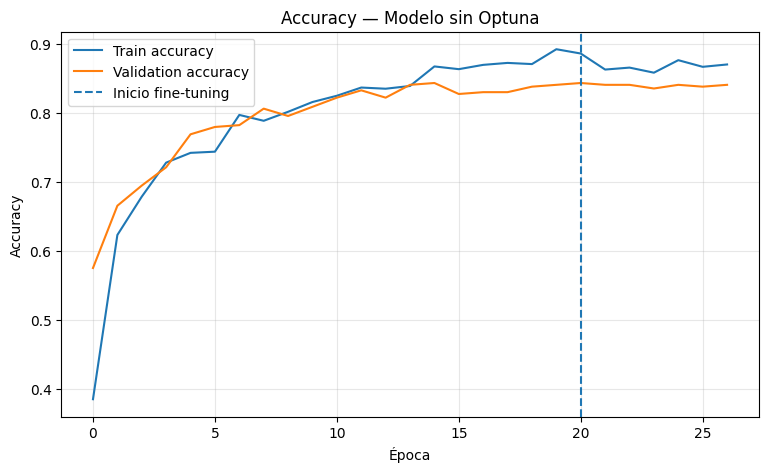

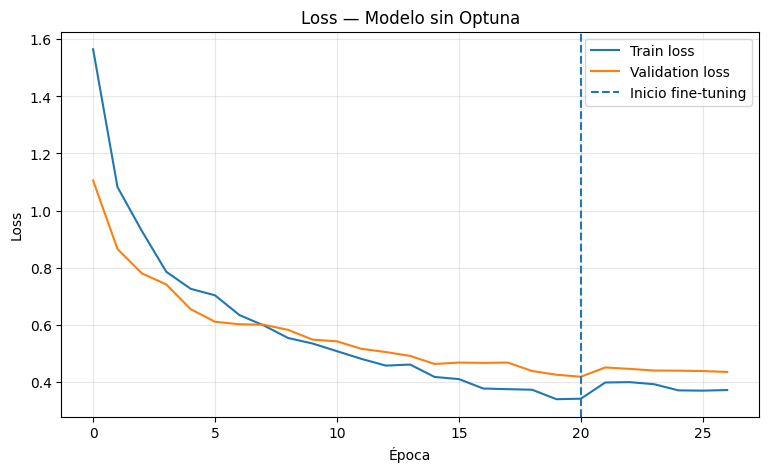

In [21]:
# 21. Curvas de entrenamiento: modelo sin Optuna

def unir_historiales(history_fase1, history_fase2):
    resultado = {}

    for metrica in ["accuracy", "val_accuracy", "loss", "val_loss"]:
        resultado[metrica] = (
            history_fase1.history[metrica]
            + history_fase2.history[metrica]
        )

    resultado["inicio_fine_tuning"] = len(
        history_fase1.history["accuracy"]
    )

    return resultado

hist_base = unir_historiales(
    history_base_fase1,
    history_base_fase2
)

plt.figure(figsize=(9, 5))
plt.plot(hist_base["accuracy"], label="Train accuracy")
plt.plot(hist_base["val_accuracy"], label="Validation accuracy")
plt.axvline(
    hist_base["inicio_fine_tuning"] - 1,
    linestyle="--",
    label="Inicio fine-tuning"
)
plt.title("Accuracy — Modelo sin Optuna")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(hist_base["loss"], label="Train loss")
plt.plot(hist_base["val_loss"], label="Validation loss")
plt.axvline(
    hist_base["inicio_fine_tuning"] - 1,
    linestyle="--",
    label="Inicio fine-tuning"
)
plt.title("Loss — Modelo sin Optuna")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


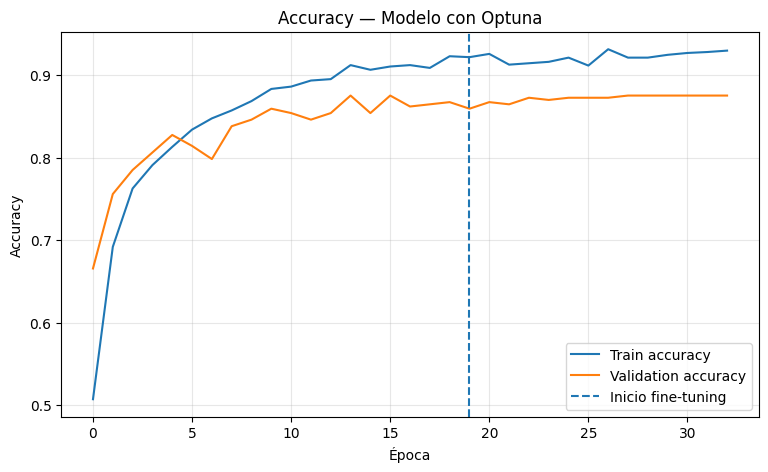

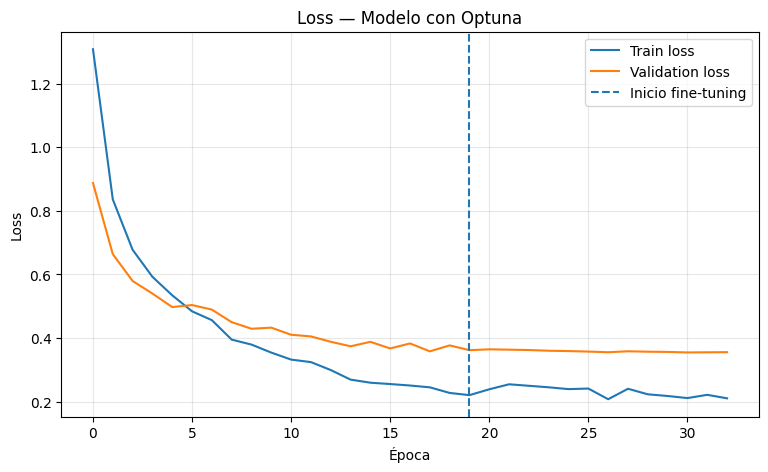

In [22]:
# 22. Curvas de entrenamiento: modelo con Optuna

hist_optuna = unir_historiales(
    history_optuna_fase1,
    history_optuna_fase2
)

plt.figure(figsize=(9, 5))
plt.plot(hist_optuna["accuracy"], label="Train accuracy")
plt.plot(hist_optuna["val_accuracy"], label="Validation accuracy")
plt.axvline(
    hist_optuna["inicio_fine_tuning"] - 1,
    linestyle="--",
    label="Inicio fine-tuning"
)
plt.title("Accuracy — Modelo con Optuna")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(hist_optuna["loss"], label="Train loss")
plt.plot(hist_optuna["val_loss"], label="Validation loss")
plt.axvline(
    hist_optuna["inicio_fine_tuning"] - 1,
    linestyle="--",
    label="Inicio fine-tuning"
)
plt.title("Loss — Modelo con Optuna")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [23]:
# 23. Reportes de clasificación

print("=" * 70)
print("REPORTE DE CLASIFICACIÓN — SIN OPTUNA")
print("=" * 70)
print(
    classification_report(
        y_true,
        y_pred_base,
        target_names=CLASSES,
        digits=4,
        zero_division=0
    )
)

print("=" * 70)
print("REPORTE DE CLASIFICACIÓN — CON OPTUNA")
print("=" * 70)
print(
    classification_report(
        y_true,
        y_pred_optuna,
        target_names=CLASSES,
        digits=4,
        zero_division=0
    )
)


REPORTE DE CLASIFICACIÓN — SIN OPTUNA
              precision    recall  f1-score   support

   cardboard     0.8235    0.9180    0.8682        61
       glass     0.8163    0.5263    0.6400        76
       metal     0.7037    0.9194    0.7972        62
       paper     0.9036    0.8333    0.8671        90
     plastic     0.8052    0.8493    0.8267        73
       trash     0.6154    0.7273    0.6667        22

    accuracy                         0.7969       384
   macro avg     0.7780    0.7956    0.7776       384
weighted avg     0.8061    0.7969    0.7919       384

REPORTE DE CLASIFICACIÓN — CON OPTUNA
              precision    recall  f1-score   support

   cardboard     0.8485    0.9180    0.8819        61
       glass     0.7719    0.5789    0.6617        76
       metal     0.6951    0.9194    0.7917        62
       paper     0.9277    0.8556    0.8902        90
     plastic     0.8451    0.8219    0.8333        73
       trash     0.6400    0.7273    0.6809        22

 

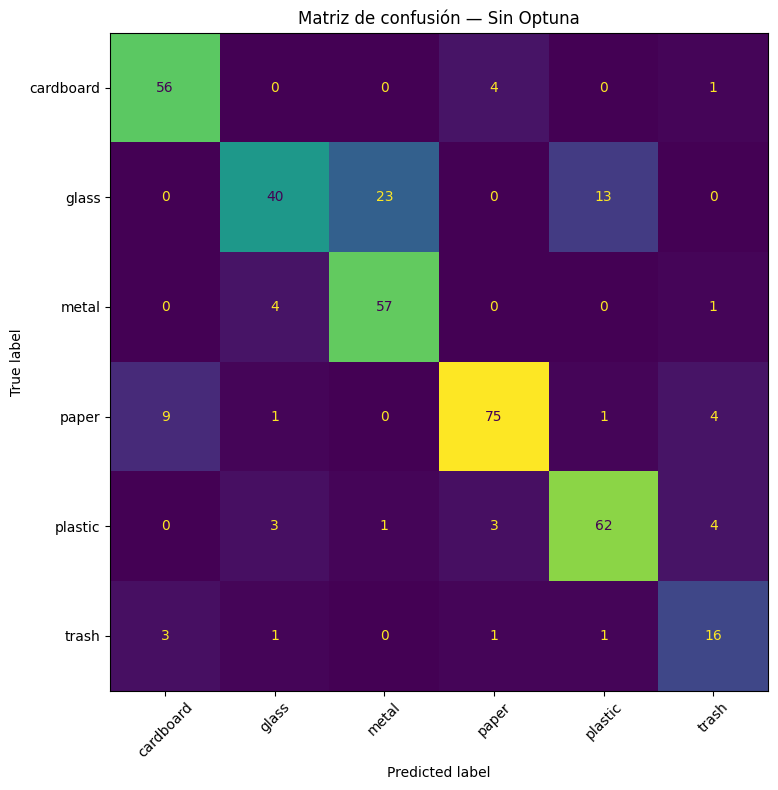

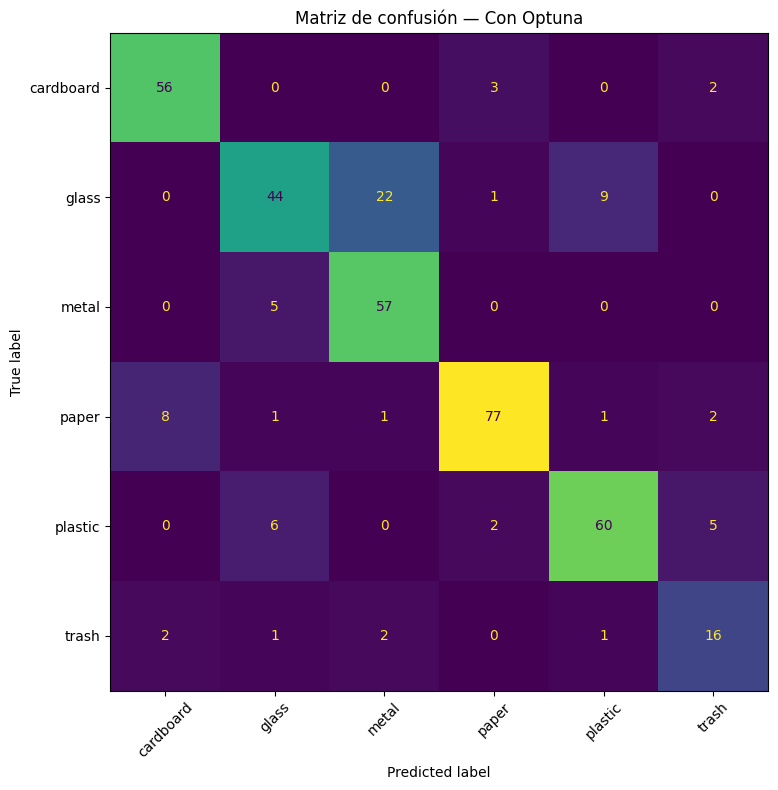

In [24]:
# 24. Matrices de confusión

cm_base = confusion_matrix(y_true, y_pred_base)
cm_optuna = confusion_matrix(y_true, y_pred_optuna)

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(
    confusion_matrix=cm_base,
    display_labels=CLASSES
).plot(
    ax=ax,
    values_format="d",
    xticks_rotation=45,
    colorbar=False
)
plt.title("Matriz de confusión — Sin Optuna")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(
    confusion_matrix=cm_optuna,
    display_labels=CLASSES
).plot(
    ax=ax,
    values_format="d",
    xticks_rotation=45,
    colorbar=False
)
plt.title("Matriz de confusión — Con Optuna")
plt.tight_layout()
plt.show()


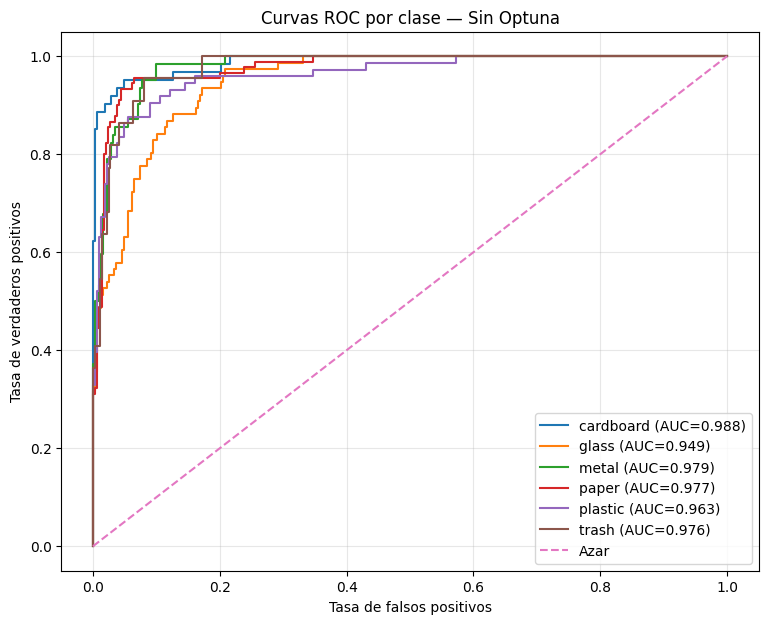

In [25]:
# 25. Curvas ROC por clase — Sin Optuna

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(N_CLASSES)
)

def graficar_roc_por_clase(y_bin, y_prob, titulo):
    plt.figure(figsize=(9, 7))

    aucs = {}

    for i, clase in enumerate(CLASSES):
        fpr, tpr, _ = roc_curve(
            y_bin[:, i],
            y_prob[:, i]
        )
        roc_auc = auc(fpr, tpr)
        aucs[clase] = roc_auc

        plt.plot(
            fpr,
            tpr,
            label=f"{clase} (AUC={roc_auc:.3f})"
        )

    plt.plot([0, 1], [0, 1], linestyle="--", label="Azar")
    plt.xlabel("Tasa de falsos positivos")
    plt.ylabel("Tasa de verdaderos positivos")
    plt.title(titulo)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    return aucs

auc_clases_base = graficar_roc_por_clase(
    y_true_bin,
    y_prob_base,
    "Curvas ROC por clase — Sin Optuna"
)


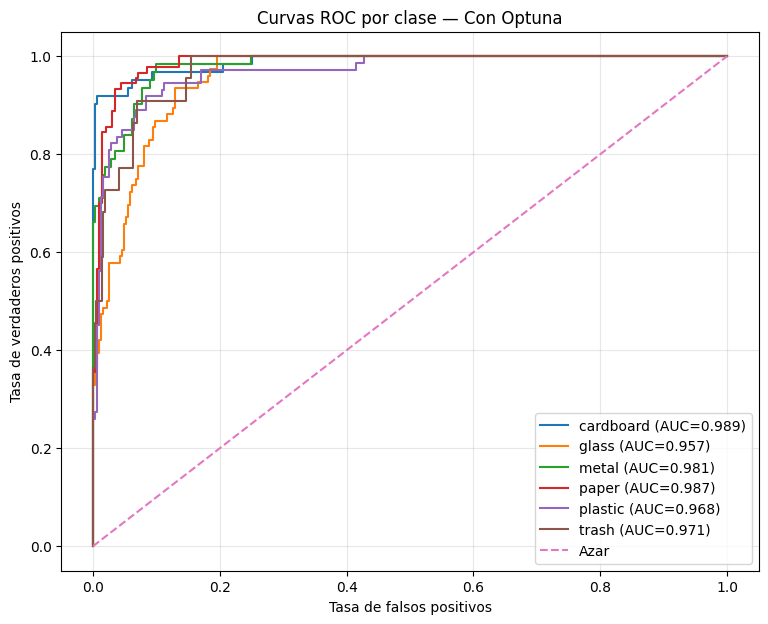

In [26]:
# 26. Curvas ROC por clase — Con Optuna

auc_clases_optuna = graficar_roc_por_clase(
    y_true_bin,
    y_prob_optuna,
    "Curvas ROC por clase — Con Optuna"
)


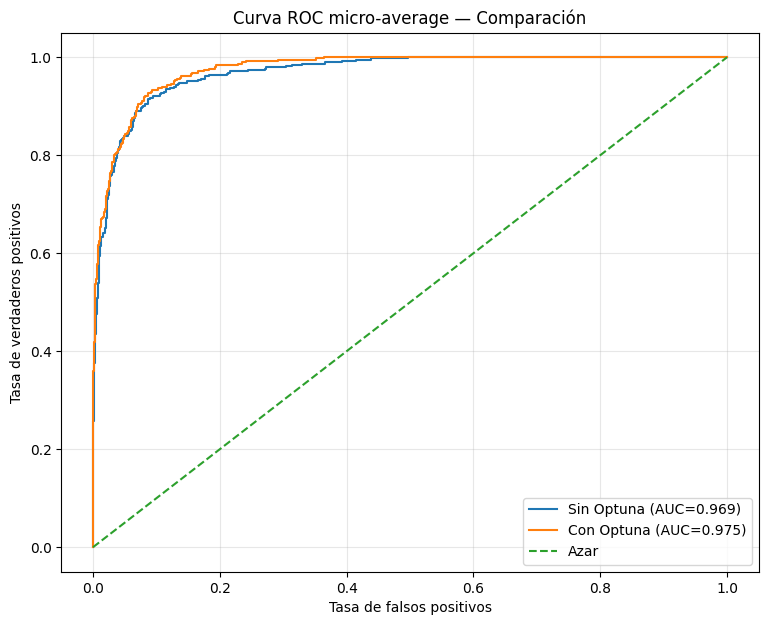

In [27]:
# 27. Comparación ROC micro-average

fpr_base_micro, tpr_base_micro, _ = roc_curve(
    y_true_bin.ravel(),
    y_prob_base.ravel()
)

fpr_optuna_micro, tpr_optuna_micro, _ = roc_curve(
    y_true_bin.ravel(),
    y_prob_optuna.ravel()
)

auc_base_micro = auc(
    fpr_base_micro,
    tpr_base_micro
)

auc_optuna_micro = auc(
    fpr_optuna_micro,
    tpr_optuna_micro
)

plt.figure(figsize=(9, 7))

plt.plot(
    fpr_base_micro,
    tpr_base_micro,
    label=f"Sin Optuna (AUC={auc_base_micro:.3f})"
)

plt.plot(
    fpr_optuna_micro,
    tpr_optuna_micro,
    label=f"Con Optuna (AUC={auc_optuna_micro:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Azar")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC micro-average — Comparación")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


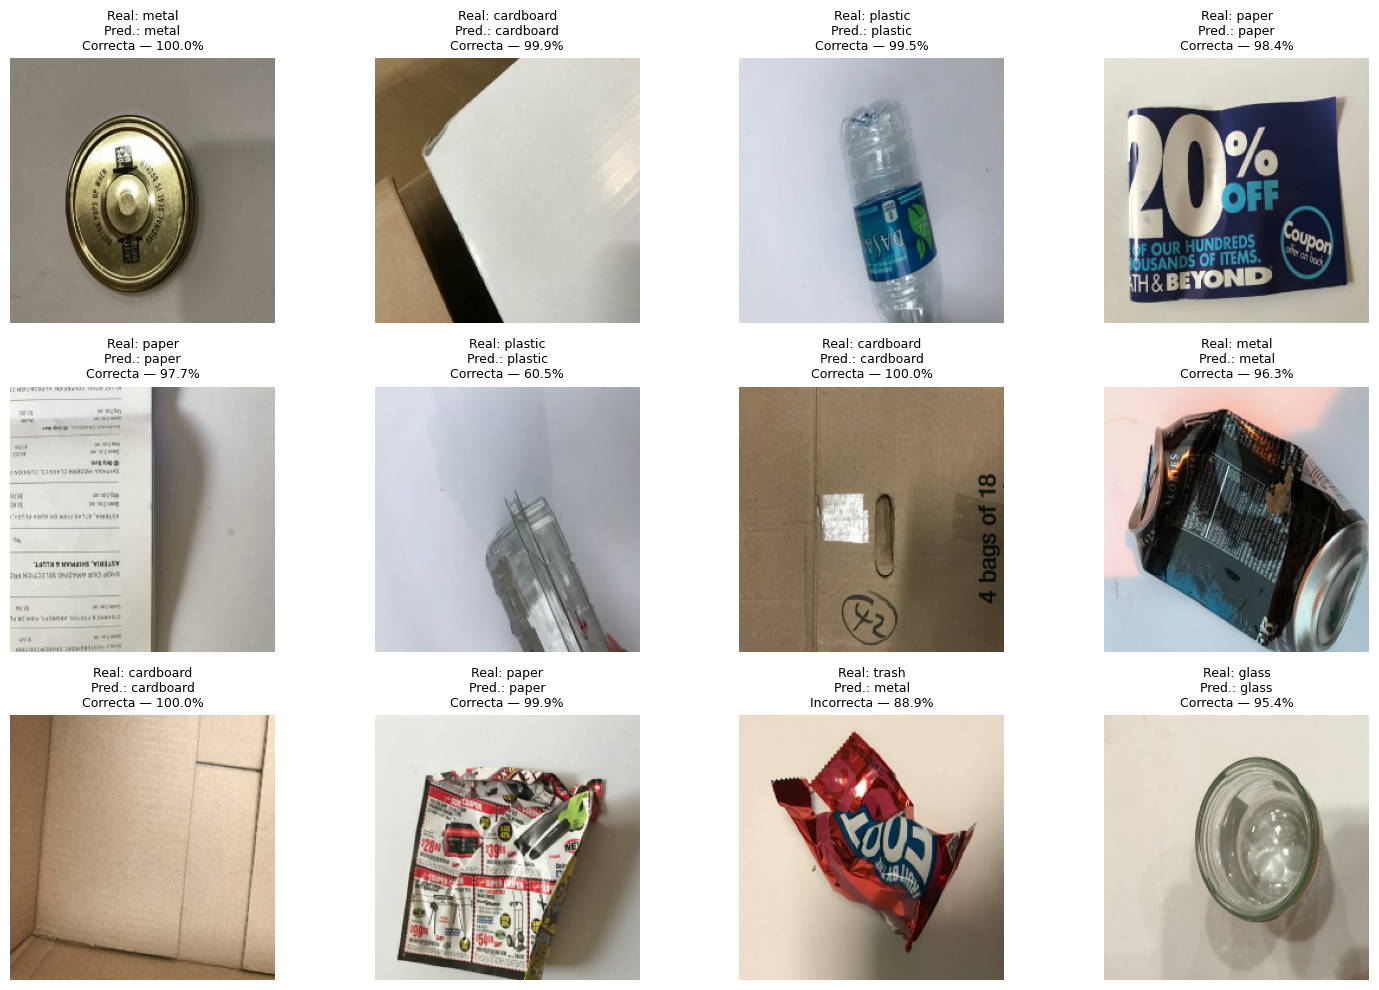

In [28]:
# 28. Predicciones aleatorias del modelo con Optuna

images_all = []
labels_all = []

for images, labels in test_ds:
    images_all.append(images.numpy())
    labels_all.append(labels.numpy())

images_all = np.concatenate(images_all)
labels_all = np.concatenate(labels_all)

rng = np.random.default_rng(SEED)
indices = rng.choice(
    len(images_all),
    size=min(12, len(images_all)),
    replace=False
)

selected_images = images_all[indices]
selected_labels = labels_all[indices]

selected_prob = model_optuna.predict(
    selected_images,
    verbose=0
)

plt.figure(figsize=(15, 10))

for i in range(len(indices)):
    true_index = int(np.argmax(selected_labels[i]))
    pred_index = int(np.argmax(selected_prob[i]))
    confidence = float(selected_prob[i][pred_index])

    plt.subplot(3, 4, i + 1)
    plt.imshow(selected_images[i].astype("uint8"))

    estado = "Correcta" if true_index == pred_index else "Incorrecta"

    plt.title(
        f"Real: {CLASSES[true_index]}\n"
        f"Pred.: {CLASSES[pred_index]}\n"
        f"{estado} — {confidence:.1%}",
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


In [29]:
# 29. Resumen final imprimible

print("=" * 76)
print("RESUMEN FINAL — TRASHNET MOBILENETV3SMALL")
print("=" * 76)

print("\nDATASET")
print(f"- Train: {sum(train_count.values())} imágenes")
print(f"- Validation: {sum(valid_count.values())} imágenes")
print(f"- Test: {sum(test_count.values())} imágenes")
print(f"- Clases: {N_CLASSES}")
print(f"- Tamaño de entrada: {IMG_SIZE}")
print(f"- Batch size: {BATCH_SIZE}")

print("\nMODELO SIN OPTUNA")
print(f"- Dense units: {BASE_DENSE_UNITS}")
print(f"- Dropout: {BASE_DROPOUT}")
print(f"- Learning rate fase 1: {BASE_LR}")
print(f"- Optimizador: {BASE_OPTIMIZER}")
print(f"- Accuracy test: {metricas_base['Accuracy']:.2%}")
print(f"- Precision macro: {metricas_base['Precision macro']:.2%}")
print(f"- Recall macro: {metricas_base['Recall macro']:.2%}")
print(f"- F1 macro: {metricas_base['F1 macro']:.2%}")
print(f"- ROC AUC macro OVR: {metricas_base['ROC AUC macro OVR']:.4f}")

print("\nMODELO CON OPTUNA")
print(f"- Trials: {OPTUNA_TRIALS}")
print(f"- Mejor trial: {study.best_trial.number}")
print(f"- Dense units: {BEST_DENSE_UNITS}")
print(f"- Dropout: {BEST_DROPOUT}")
print(f"- Learning rate fase 1: {BEST_LR:.8f}")
print(f"- Optimizador: {BEST_OPTIMIZER}")
print(f"- Accuracy test: {metricas_optuna['Accuracy']:.2%}")
print(f"- Precision macro: {metricas_optuna['Precision macro']:.2%}")
print(f"- Recall macro: {metricas_optuna['Recall macro']:.2%}")
print(f"- F1 macro: {metricas_optuna['F1 macro']:.2%}")
print(f"- ROC AUC macro OVR: {metricas_optuna['ROC AUC macro OVR']:.4f}")

print("\nCOMPARACIÓN")
print(f"- Diferencia de accuracy: {diferencia:+.2%}")
print(f"- AUC micro sin Optuna: {auc_base_micro:.4f}")
print(f"- AUC micro con Optuna: {auc_optuna_micro:.4f}")

mejor_modelo = (
    "Con Optuna"
    if metricas_optuna["Accuracy"] > metricas_base["Accuracy"]
    else "Sin Optuna"
    if metricas_optuna["Accuracy"] < metricas_base["Accuracy"]
    else "Empate"
)

print(f"- Mejor accuracy en test: {mejor_modelo}")

print("\nARCHIVOS")
print(f"- Modelo sin Optuna: {RUTA_MODELO_BASE}")
print(f"- Modelo con Optuna: {RUTA_MODELO_OPTUNA}")
print("=" * 76)


RESUMEN FINAL — TRASHNET MOBILENETV3SMALL

DATASET
- Train: 1766 imágenes
- Validation: 377 imágenes
- Test: 384 imágenes
- Clases: 6
- Tamaño de entrada: (224, 224)
- Batch size: 32

MODELO SIN OPTUNA
- Dense units: 128
- Dropout: 0.35
- Learning rate fase 1: 0.0003
- Optimizador: adam
- Accuracy test: 79.69%
- Precision macro: 77.80%
- Recall macro: 79.56%
- F1 macro: 77.76%
- ROC AUC macro OVR: 0.9721

MODELO CON OPTUNA
- Trials: 10
- Mejor trial: 1
- Dense units: 64
- Dropout: 0.2
- Learning rate fase 1: 0.00087060
- Optimizador: adam
- Accuracy test: 80.73%
- Precision macro: 78.81%
- Recall macro: 80.35%
- F1 macro: 78.99%
- ROC AUC macro OVR: 0.9753

COMPARACIÓN
- Diferencia de accuracy: +1.04%
- AUC micro sin Optuna: 0.9688
- AUC micro con Optuna: 0.9751
- Mejor accuracy en test: Con Optuna

ARCHIVOS
- Modelo sin Optuna: modelo_guardado\trashnet_mobilenetv3_sin_optuna.keras
- Modelo con Optuna: modelo_guardado\trashnet_mobilenetv3_optuna.keras
